<a href="https://colab.research.google.com/github/emmanuelvillada573/laboratorio1/blob/main/ML_Data_Mining_Sentiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================
# Taller: Análisis de Opiniones de Clientes
# Data Mining / Text Mining
# ==========================

# 1. Instalar librerías necesarias
!pip install nltk pandas matplotlib wordcloud

In [4]:
# 2. Importar librerías
import pandas as pd
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Descargar recursos de NLTK (solo la primera vez)
nltk.download('punkt')

# 3. Cargar datos
# Subir archivo comments_for_powerbi.xlsx desde tu computador en Colab
from google.colab import files
uploaded = files.upload()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Saving Comentarios - Comentarios (1).csv to Comentarios - Comentarios (1) (1).csv


In [11]:
import io
# Leer archivo Excel
print(uploaded)
# Get the content of the first (and only) uploaded file
file_content = list(uploaded.values())[0]
df = pd.read_csv(io.BytesIO(file_content))
print("Primeras filas del dataset:")
print(df.head())

{'Comentarios - Comentarios (1) (1).csv': b'Comentario\r\nLa comida fue excelente y el servicio fue excepcional. Definitivamente volver\xc3\xa9.\r\n"El ambiente era agradable y la comida estaba deliciosa, aunque un poco cara."\r\n"La comida estaba bien, pero el servicio fue lento y poco atento."\r\n"No me gust\xc3\xb3 la comida, estaba fr\xc3\xada y el sabor no era bueno."\r\nEl peor restaurante en el que he estado. No lo recomiendo para nada.\r\n\xc2\xa1Incre\xc3\xadble! El mejor lugar para cenar con amigos o familiares.\r\nBuena comida y buena m\xc3\xbasica. Un lugar agradable para pasar el rato.\r\n"La comida era decente, pero no vale el precio que cobran."\r\nEl servicio fue terrible y la comida lleg\xc3\xb3 tarde y fr\xc3\xada.\r\nMuy mala experiencia. El personal fue grosero y la comida horrible.\r\nExcelente lugar. La comida y el servicio fueron perfectos.\r\nEl restaurante tiene un buen ambiente y la comida es sabrosa.\r\n"Regular, nada especial. No creo que vuelva pronto."\r\n

In [12]:
# 4. Definir listas de palabras positivas y negativas
positivas = ["excelente","bueno","buena","recomiendo","encanta","perfecto","increíble","mejor","genial","rápido","calidad"]
negativas = ["defectuoso","malo","mala","lento","decepcionante","no recomiendo","no vale","problemas","descontento","falta"]

# 5. Función de clasificación simple
def clasificar_sentimiento(texto):
    t = texto.lower()
    pos = sum(1 for p in positivas if p in t)
    neg = sum(1 for n in negativas if n in t)
    if pos > neg:
        return "Positivo"
    elif neg > pos:
        return "Negativo"
    else:
        return "Neutro"

In [13]:
# 6. Aplicar clasificación
df["Sentimiento"] = df["Comentario"].apply(clasificar_sentimiento)

# 7. Resumen de resultados
print("\nConteo por categoría de sentimiento:")
print(df["Sentimiento"].value_counts())


Conteo por categoría de sentimiento:
Sentimiento
Neutro      33
Positivo    24
Negativo    14
Name: count, dtype: int64


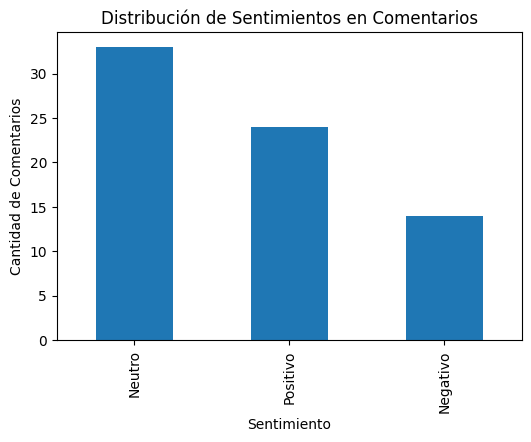

In [14]:
# 8. Visualización: gráfico de barras
df["Sentimiento"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Distribución de Sentimientos en Comentarios")
plt.ylabel("Cantidad de Comentarios")
plt.show()

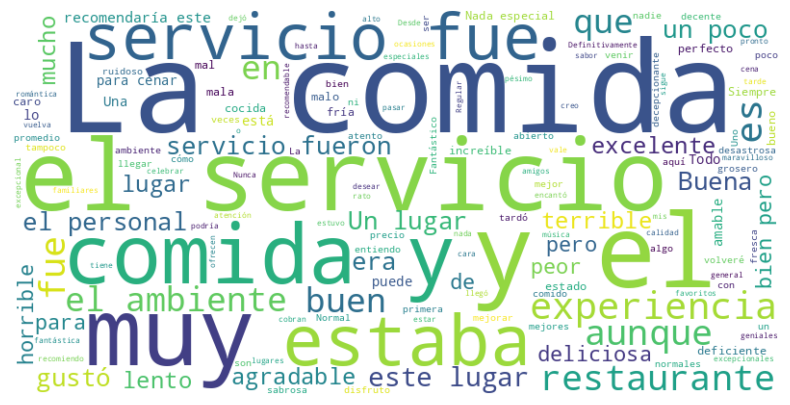

In [15]:
# 9. Visualización: nube de palabras
texto_total = " ".join(df["Comentario"].tolist())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(texto_total)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()